# 03 — Results Analysis

**Project:** Robust Biometric Signature Verification Against Skilled Forgeries

Analyzes a trained checkpoint's training curves and held-out TEST
performance, using the artifacts written by `train_baseline.py` and
`evaluate_checkpoint.py`. Sections:

1. Training dynamics — loss/EER/AUC vs. epoch, best-epoch marker
2. ROC + DET curves — all pairs vs. skilled-only subset
3. Distance distributions by pair kind, with threshold markers
4. FAR/FRR vs. threshold sweep, EER and operating-point markers
5. Metrics summary table (test + selected-checkpoint info + confusion
   metrics at the val-chosen threshold)
6. Optional comparison against a second experiment directory
7. Bootstrap CI on test EER — resamples *writers* (not pairs) and adds a
   per-writer EER breakdown when `test_scores.csv` carries `writer_a`/
   `writer_b` columns; falls back to a pair-level bootstrap (with no
   per-writer table) on older runs that lack them

**Conventions**
- Decision rule: accept a pair iff `distance < threshold`. Label 1 =
  positive (genuine, same-writer). FAR = accepted negatives / all
  negatives; FRR = rejected positives / all positives.
- Figures -> `report/figures/results/`, tables -> `report/dataset_checks/`
  with a `results_` prefix.
- `RNG_SEED = 42` for every random/bootstrap operation.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sigver.evaluation.metrics import compute_eer, roc_auc, far_frr_curve

sns.set_theme(style="whitegrid", context="notebook")
RNG_SEED = 42
np.random.seed(RNG_SEED)

_here = Path.cwd()
PROJECT_ROOT = _here if (_here / "experiments").is_dir() else _here.parent
assert (PROJECT_ROOT / "experiments").is_dir(), (
    f"Could not locate experiments/ relative to {_here}. "
    "Run from the project root or the notebooks/ folder."
)

EXP_DIR = PROJECT_ROOT / "experiments" / "siamese_smallcnn_cedar"
EXP_DIR_OLD: Optional[Path] = PROJECT_ROOT / "experiments" / "siamese_smallcnn_cedar_v1_morph"
# EXP_DIR_OLD's best_model.pt/history.json/best_info.json are genuinely the
# v1 (MorphAugment) run, but its test_metrics.json/test_scores.csv predate
# that run and are actually the older v0 (grayscale-pipeline) test
# evaluation -- v1 itself was never test-evaluated. See the provenance note
# in Section 6.
EXP_DIR_OLD_LABEL = "v0 grayscale pipeline"

FIG_DIR = PROJECT_ROOT / "report" / "figures" / "results"
TABLE_DIR = PROJECT_ROOT / "report" / "dataset_checks"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"EXP_DIR      : {EXP_DIR}")
print(f"EXP_DIR_OLD  : {EXP_DIR_OLD} (labelled '{EXP_DIR_OLD_LABEL}')")


def savefig(fig: plt.Figure, name: str) -> None:
    """Save a figure to report/figures/results/<name>.png at print quality."""
    out = FIG_DIR / f"{name}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    print(f"  saved -> {out.relative_to(PROJECT_ROOT)}")

Project root : C:\Users\nehas\Downloads\robust-signature-verification
EXP_DIR      : C:\Users\nehas\Downloads\robust-signature-verification\experiments\siamese_smallcnn_cedar
EXP_DIR_OLD  : C:\Users\nehas\Downloads\robust-signature-verification\experiments\siamese_smallcnn_cedar_v1_morph (labelled 'v0 grayscale pipeline')


## Artifact loaders

`best_info.json` is not guaranteed to exist (older runs) and, even when
present, may lack the `selected_by` key. Fall back to
`argmin(val_eer_all)` over `history.json` when the file is missing, and
print which path was taken.

In [2]:
def load_json(path: Path) -> dict:
    return json.loads(path.read_text())


def get_best_info(exp_dir: Path, history: list[dict]) -> dict:
    path = exp_dir / "best_info.json"
    if path.exists():
        info = load_json(path)
        if "selected_by" not in info:
            print(f"[{exp_dir.name}] best_info.json found but missing "
                  "'selected_by' (older run format)")
        else:
            print(f"[{exp_dir.name}] best_info.json selected_by: "
                  f"{info['selected_by']}")
        return info
    print(f"[{exp_dir.name}] best_info.json not found -> falling back to "
          "argmin(val_eer_all) over history.json")
    best = dict(min(history, key=lambda h: h["val_eer_all"]))
    best["selected_by"] = "argmin val_eer_all (fallback: best_info.json missing)"
    return best


def load_experiment(exp_dir: Path) -> dict:
    """Load config, history, best_info, test_metrics, test_scores for one run."""
    config = load_json(exp_dir / "config.json")
    history = load_json(exp_dir / "history.json")
    best_info = get_best_info(exp_dir, history)
    test_metrics = load_json(exp_dir / "test_metrics.json")
    test_scores = pd.read_csv(exp_dir / "test_scores.csv")
    return dict(config=config, history=history, best_info=best_info,
               test_metrics=test_metrics, test_scores=test_scores)


exp = load_experiment(EXP_DIR)
config, history, best_info, test_metrics, test_scores = (
    exp["config"], exp["history"], exp["best_info"], exp["test_metrics"],
    exp["test_scores"],
)
hist_df = pd.DataFrame(history)
print(f"\nEpochs: {len(hist_df)}, test pairs: {len(test_scores):,}")
print(f"Best epoch: {best_info['epoch']} (val_eer_all={best_info['val_eer_all']})")
test_scores["kind"].value_counts()

[siamese_smallcnn_cedar] best_info.json selected_by: min val_eer_all

Epochs: 10, test pairs: 6,072
Best epoch: 2 (val_eer_all=0.1241)


kind
positive    3036
random      1518
skilled     1518
Name: count, dtype: int64

## 1. Training dynamics

Train loss and validation EER (all pairs, skilled-only) vs. epoch, plus
validation AUC. A vertical marker highlights the epoch whose checkpoint
was actually saved (per `best_info.json`, or the fallback above).

  saved -> report\figures\results\results_training_dynamics.png


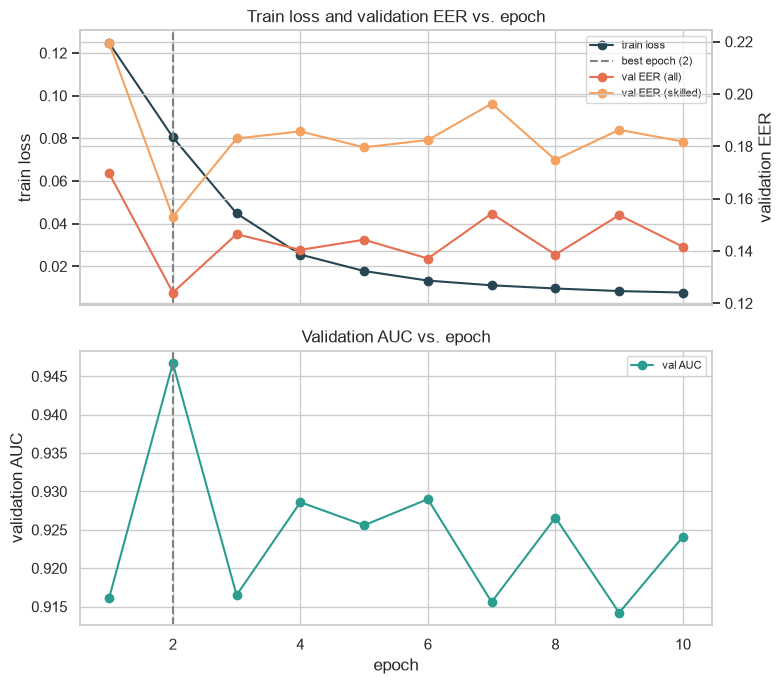

In [3]:
best_epoch = best_info["epoch"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

ax1.plot(hist_df["epoch"], hist_df["train_loss"], "o-", color="#264653",
        label="train loss")
ax1.set_ylabel("train loss")
ax1.axvline(best_epoch, color="gray", linestyle="--",
           label=f"best epoch ({best_epoch})")

ax1b = ax1.twinx()
ax1b.plot(hist_df["epoch"], hist_df["val_eer_all"], "o-", color="#e76f51",
         label="val EER (all)")
ax1b.plot(hist_df["epoch"], hist_df["val_eer_skilled"], "o-", color="#f4a261",
         label="val EER (skilled)")
ax1b.set_ylabel("validation EER")

lines1, labels1 = ax1.get_legend_handles_labels()
lines1b, labels1b = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines1b, labels1 + labels1b, fontsize=8, loc="upper right")
ax1.set_title("Train loss and validation EER vs. epoch")

ax2.plot(hist_df["epoch"], hist_df["val_auc"], "o-", color="#2a9d8f",
        label="val AUC")
ax2.axvline(best_epoch, color="gray", linestyle="--")
ax2.set_xlabel("epoch")
ax2.set_ylabel("validation AUC")
ax2.set_title("Validation AUC vs. epoch")
ax2.legend(fontsize=8)

fig.tight_layout()
savefig(fig, "results_training_dynamics")
plt.show()

## 2. ROC + DET curves

ROC and DET computed from `test_scores.csv` for all pairs and for the
skilled-only subset (`kind` in `{positive, skilled}`, i.e. the
random-forgery pairs excluded). Both reuse
`sigver.evaluation.metrics.far_frr_curve`/`roc_auc` — ROC's TPR is
`1 - FRR`; the DET axes are FAR/FRR directly.

  saved -> report\figures\results\results_roc_det.png


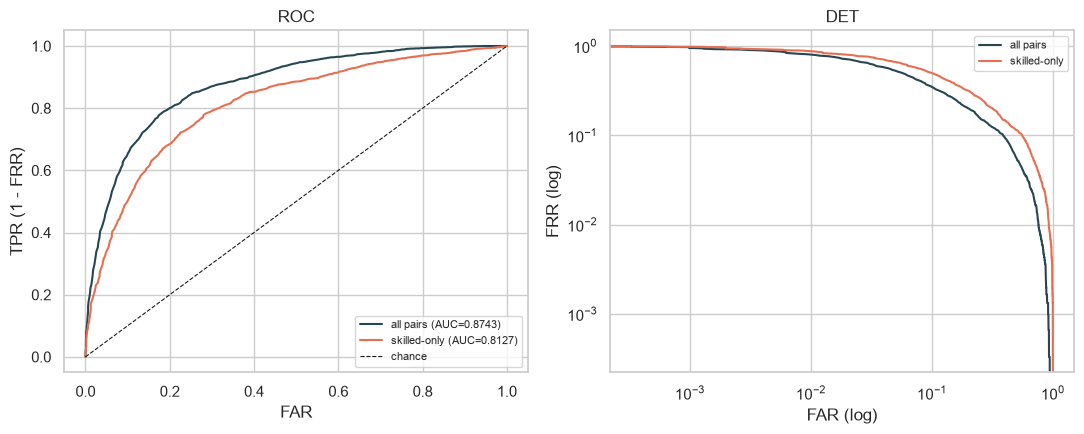

In [4]:
skilled_mask = test_scores["kind"].isin(["positive", "skilled"])

curves = {
    "all pairs": test_scores,
    "skilled-only": test_scores[skilled_mask],
}

fig, (ax_roc, ax_det) = plt.subplots(1, 2, figsize=(11, 4.5))
colors = {"all pairs": "#264653", "skilled-only": "#e76f51"}

for name, sub in curves.items():
    d = sub["distance"].to_numpy()
    y = sub["label"].to_numpy()
    thr, far, frr = far_frr_curve(d, y)
    tpr = 1.0 - frr
    auc = roc_auc(d, y)
    ax_roc.plot(far, tpr, color=colors[name], label=f"{name} (AUC={auc:.4f})")
    ax_det.plot(far, frr, color=colors[name], label=name)

ax_roc.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="chance")
ax_roc.set_xlabel("FAR")
ax_roc.set_ylabel("TPR (1 - FRR)")
ax_roc.set_title("ROC")
ax_roc.legend(fontsize=8)

ax_det.set_xscale("log")
ax_det.set_yscale("log")
ax_det.set_xlabel("FAR (log)")
ax_det.set_ylabel("FRR (log)")
ax_det.set_title("DET")
ax_det.legend(fontsize=8)

fig.tight_layout()
savefig(fig, "results_roc_det")
plt.show()

## 3. Distance distributions

Distribution of embedding distance by pair kind (positive, skilled
forgery, random forgery), with reference lines at the validation
operating threshold and the test-set EER threshold (diagnostic only —
not used to make decisions).

  saved -> report\figures\results\results_distance_distributions.png


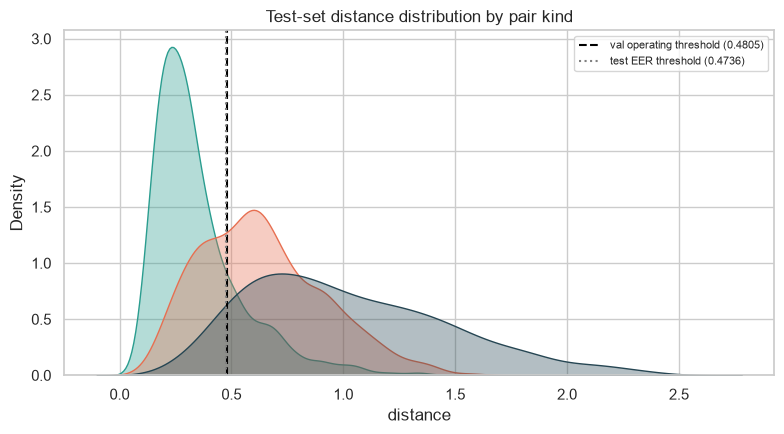

In [5]:
op_thr = test_metrics["operating_threshold_from_val"]
eer_thr = test_metrics["test_eer_threshold"]

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.kdeplot(data=test_scores, x="distance", hue="kind", common_norm=False,
           fill=True, alpha=0.35,
           palette={"positive": "#2a9d8f", "skilled": "#e76f51",
                    "random": "#264653"}, ax=ax)
ax.axvline(op_thr, color="black", linestyle="--",
          label=f"val operating threshold ({op_thr:.4f})")
ax.axvline(eer_thr, color="gray", linestyle=":",
          label=f"test EER threshold ({eer_thr:.4f})")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, fontsize=8)
ax.set_title("Test-set distance distribution by pair kind")
fig.tight_layout()
savefig(fig, "results_distance_distributions")
plt.show()

## 4. FAR/FRR vs. threshold sweep

Local implementation: `metrics.far_frr_curve` sweeps a fixed-size
linspace and uses an accept-iff-`distance <= threshold` convention. Here
we sweep every unique observed distance and use this notebook's
accept-iff-`distance < threshold` convention (matching
`evaluate_checkpoint.py`'s `far_frr_at_threshold`), so the plotted curve
and the marked points are self-consistent.

  saved -> report\figures\results\results_far_frr_curve.png


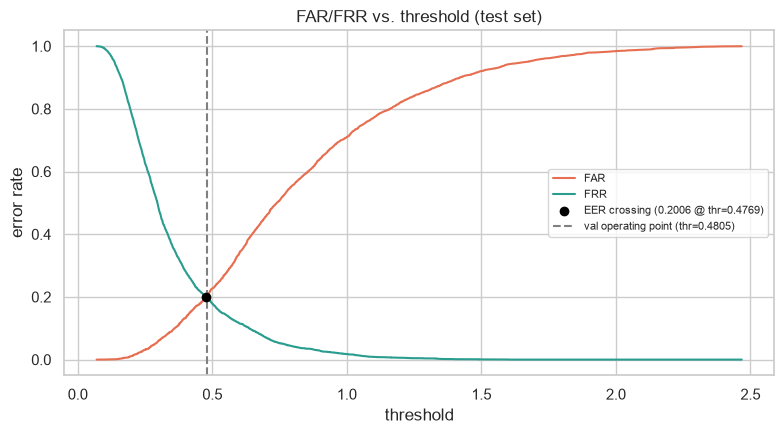

EER (metrics.compute_eer): 0.1996 @ threshold 0.4736
EER (local sweep crossing): 0.2006 @ threshold 0.4769


In [6]:
def far_frr_sweep(distances: np.ndarray, labels: np.ndarray,
                  thresholds: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """FAR/FRR at each threshold, accept iff distance < threshold."""
    pos = distances[labels == 1]
    neg = distances[labels == 0]
    far = np.array([(neg < t).mean() for t in thresholds])
    frr = np.array([(pos >= t).mean() for t in thresholds])
    return far, frr


dist_all = test_scores["distance"].to_numpy()
label_all = test_scores["label"].to_numpy()
thresholds = np.unique(dist_all)
far_sweep, frr_sweep = far_frr_sweep(dist_all, label_all, thresholds)

eer_all, eer_thr_all = compute_eer(dist_all, label_all)
eer_idx = int(np.argmin(np.abs(far_sweep - frr_sweep)))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thresholds, far_sweep, color="#e76f51", label="FAR")
ax.plot(thresholds, frr_sweep, color="#2a9d8f", label="FRR")
ax.scatter([thresholds[eer_idx]], [far_sweep[eer_idx]], color="black", zorder=5,
          label=f"EER crossing ({far_sweep[eer_idx]:.4f} @ "
                f"thr={thresholds[eer_idx]:.4f})")
ax.axvline(op_thr, color="gray", linestyle="--",
          label=f"val operating point (thr={op_thr:.4f})")
ax.set_xlabel("threshold")
ax.set_ylabel("error rate")
ax.set_title("FAR/FRR vs. threshold (test set)")
ax.legend(fontsize=8)
fig.tight_layout()
savefig(fig, "results_far_frr_curve")
plt.show()

print(f"EER (metrics.compute_eer): {eer_all:.4f} @ threshold {eer_thr_all:.4f}")
print(f"EER (local sweep crossing): {(far_sweep[eer_idx] + frr_sweep[eer_idx]) / 2:.4f} "
     f"@ threshold {thresholds[eer_idx]:.4f}")

## 5. Metrics summary table

Merges `test_metrics.json` with the selected checkpoint's `best_info`
entry, then adds precision/recall/F1/accuracy at the validation-chosen
operating threshold, computed over all test pairs (positive = label 1;
skilled + random combined as negative), per the accept-iff-`distance <
threshold` convention.

In [7]:
accepted = dist_all < op_thr
is_pos = label_all == 1

tp = int((accepted & is_pos).sum())
fp = int((accepted & ~is_pos).sum())
fn = int((~accepted & is_pos).sum())
tn = int((~accepted & ~is_pos).sum())

precision = tp / (tp + fp) if (tp + fp) else float("nan")
recall = tp / (tp + fn) if (tp + fn) else float("nan")
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else float("nan")
accuracy = (tp + tn) / len(label_all)

summary = {
    **best_info,
    **test_metrics,
    "precision_at_val_threshold": round(precision, 4),
    "recall_at_val_threshold": round(recall, 4),
    "f1_at_val_threshold": round(f1, 4),
    "accuracy_at_val_threshold": round(accuracy, 4),
}
summary_df = pd.DataFrame([summary])
summary_df.to_csv(TABLE_DIR / "results_metrics_summary.csv", index=False)
print(f"saved -> {(TABLE_DIR / 'results_metrics_summary.csv').relative_to(PROJECT_ROOT)}")
summary_df.T

saved -> report\dataset_checks\results_metrics_summary.csv


,0
epoch,2
train_loss,0.0805
val_eer_all,0.1241
val_eer_skilled,0.1531
val_auc,0.9467
val_threshold,0.4805
seconds,2154.2
selected_by,min val_eer_all
dataset,cedar
split,test


## 6. Optional baseline comparison

Skipped cleanly (no error) if `EXP_DIR_OLD` is `None` or any of its five
expected artifact files are missing.

**Provenance note.** `EXP_DIR_OLD` points at
`experiments/siamese_smallcnn_cedar_v1_morph`. Its `best_model.pt` /
`history.json` / `best_info.json` are genuinely the v1 (MorphAugment)
training run, but its `test_metrics.json` / `test_scores.csv` predate
that run — v1 was never pushed through `evaluate_checkpoint.py`, and the
test files sitting in that folder are actually the older v0
(grayscale-pipeline) test evaluation. So everything below is labelled
"v0 grayscale pipeline" (`EXP_DIR_OLD_LABEL`), and the comparison is
v0 vs. v2, not v1 vs. v2.

[siamese_smallcnn_cedar_v1_morph] best_info.json selected_by: min val_eer_all


  saved -> report\figures\results\results_baseline_comparison.png


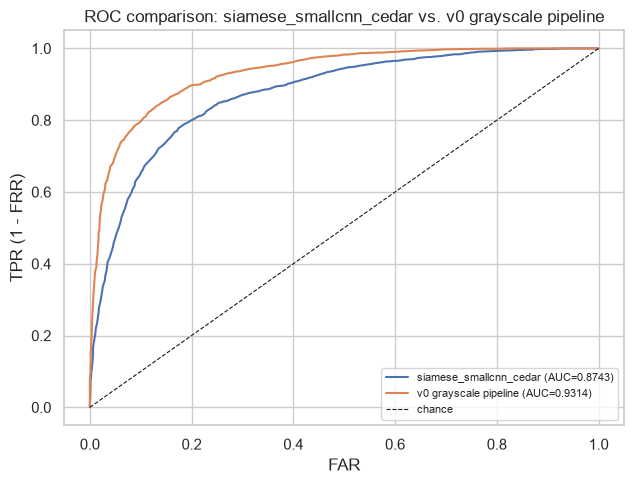

saved -> report\dataset_checks\results_baseline_comparison.csv


In [8]:
REQUIRED_FILES = ["config.json", "history.json", "test_metrics.json", "test_scores.csv"]

def artifacts_present(exp_dir: Path) -> bool:
    return all((exp_dir / f).exists() for f in REQUIRED_FILES)


if EXP_DIR_OLD is None:
    print("EXP_DIR_OLD not set -> skipping baseline comparison.")
elif not artifacts_present(EXP_DIR_OLD):
    missing = [f for f in REQUIRED_FILES if not (EXP_DIR_OLD / f).exists()]
    print(f"EXP_DIR_OLD={EXP_DIR_OLD} is missing {missing} -> skipping "
         "baseline comparison.")
else:
    exp_old = load_experiment(EXP_DIR_OLD)
    scores_old = exp_old["test_scores"]

    fig, ax = plt.subplots(figsize=(6.5, 5))
    for label_name, sub in ((EXP_DIR.name, test_scores), (EXP_DIR_OLD_LABEL, scores_old)):
        d = sub["distance"].to_numpy()
        y = sub["label"].to_numpy()
        thr, far, frr = far_frr_curve(d, y)
        auc = roc_auc(d, y)
        ax.plot(far, 1 - frr, label=f"{label_name} (AUC={auc:.4f})")
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="chance")
    ax.set_xlabel("FAR")
    ax.set_ylabel("TPR (1 - FRR)")
    ax.set_title(f"ROC comparison: {EXP_DIR.name} vs. {EXP_DIR_OLD_LABEL}")
    ax.legend(fontsize=8)
    fig.tight_layout()
    savefig(fig, "results_baseline_comparison")
    plt.show()

    comparison_df = pd.DataFrame([
        {"experiment": EXP_DIR.name, **test_metrics},
        {"experiment": EXP_DIR_OLD_LABEL, **exp_old["test_metrics"]},
    ])
    comparison_df.to_csv(TABLE_DIR / "results_baseline_comparison.csv", index=False)
    print(f"saved -> {(TABLE_DIR / 'results_baseline_comparison.csv').relative_to(PROJECT_ROOT)}")
    comparison_df

### Pipeline comparison summary (v0 vs. v1 vs. v2)

v0 and v1 figures below are fixed constants (documented in the code
cell's comment), not read from files, because their run artifacts are
partially or fully absent from this repo — see the provenance note
above. v2's figures are read live from `best_info.json` /
`test_metrics.json` so this table can't drift out of sync with the
current checkpoint.

In [9]:
# v0 (grayscale pipeline) and v1 (MorphAugment) rows are hardcoded
# constants, not derived from files in this repo:
#   v0: best val EER 0.1202 @ epoch 1, test EER 0.147, test AUC 0.931
#       -- v0's own history.json/best_info.json are not present in this
#       repo; these numbers come from the project's progress notes. (Its
#       test_metrics.json/test_scores.csv do survive, mislabeled, under
#       experiments/siamese_smallcnn_cedar_v1_morph/ -- see Section 6.)
#   v1: best val EER 0.1534 @ epoch 2, val EER skilled 0.1993, no test
#       eval -- matches experiments/siamese_smallcnn_cedar_v1_morph/best_info.json;
#       v1 was never run through evaluate_checkpoint.py.
# v2 row is read live from this run's best_info.json / test_metrics.json.

pipeline_comparison_df = pd.DataFrame([
    {
        "pipeline": "v0_grayscale",
        "best_val_eer": 0.1202,
        "best_val_epoch": 1,
        "val_eer_skilled": None,
        "test_eer_all": 0.147,
        "test_auc": 0.931,
    },
    {
        "pipeline": "v1_morph",
        "best_val_eer": 0.1534,
        "best_val_epoch": 2,
        "val_eer_skilled": 0.1993,
        "test_eer_all": None,
        "test_auc": None,
    },
    {
        "pipeline": "v2_binary",
        "best_val_eer": best_info["val_eer_all"],
        "best_val_epoch": best_info["epoch"],
        "val_eer_skilled": best_info["val_eer_skilled"],
        "test_eer_all": test_metrics["test_eer_all"],
        "test_auc": test_metrics["test_auc"],
    },
])
pipeline_comparison_df.to_csv(TABLE_DIR / "results_pipeline_comparison.csv", index=False)
print(f"saved -> {(TABLE_DIR / 'results_pipeline_comparison.csv').relative_to(PROJECT_ROOT)}")
pipeline_comparison_df

saved -> report\dataset_checks\results_pipeline_comparison.csv


,pipeline,best_val_eer,best_val_epoch,val_eer_skilled,test_eer_all,test_auc
0,v0_grayscale,0.1202,1,NaN,0.1470,0.9310
1,v1_morph,0.1534,2,0.1993,NaN,NaN
2,v2_binary,0.1241,2,0.1531,0.1996,0.8743


## 7. Per-writer analysis

`evaluate_checkpoint.py` writes `writer_a`/`writer_b` (folder-ID ground
truth for the reference/questioned side of each pair) into
`test_scores.csv`; older runs won't have these columns, so this section
checks for them and falls back to a pair-level bootstrap when absent —
that fallback cannot separate "small test set" noise from "pairs sharing
a writer are correlated" noise, so treat its CI as optimistic.

When writer columns are present: EER is computed per writer
(`results_per_writer_eer.csv`; writers with only one label present are
skipped, since EER needs both classes), and the bootstrap CI resamples
*writers* — anchored on `writer_a`, the reference/enrolled identity,
including for random-negative pairs (the standard verification framing:
the enrolled writer is the reference side) — pooling all pairs of the
sampled writers each iteration. With few test writers this CI will be
noticeably wider than the pair-level one; that width is the honest
uncertainty, not a bug.

In [10]:
def bootstrap_eer_ci(distances: np.ndarray, labels: np.ndarray,
                     n_resamples: int = 1000, seed: int = RNG_SEED) -> dict:
    """Pair-level bootstrap (fallback when writer_a/writer_b are absent)."""
    rng = np.random.default_rng(seed)
    n = len(distances)
    eers = []
    for _ in range(n_resamples):
        idx = rng.integers(0, n, size=n)
        y = labels[idx]
        if y.min() == y.max():
            continue  # degenerate resample, both classes required
        eer, _ = compute_eer(distances[idx], y)
        eers.append(eer)
    eers = np.asarray(eers)
    return {
        "point_estimate": float(np.mean(eers)),
        "ci_lower_2.5pct": float(np.percentile(eers, 2.5)),
        "ci_upper_97.5pct": float(np.percentile(eers, 97.5)),
        "n_resamples": int(len(eers)),
    }


def bootstrap_eer_ci_by_writer(df: pd.DataFrame, n_resamples: int = 1000,
                               seed: int = RNG_SEED) -> dict:
    """Resample writer_a identities with replacement, pool their pairs."""
    rng = np.random.default_rng(seed)
    groups = {w: g for w, g in df.groupby("writer_a")}
    writers = np.array(list(groups))
    eers = []
    for _ in range(n_resamples):
        sampled = rng.choice(writers, size=len(writers), replace=True)
        boot = pd.concat([groups[w] for w in sampled], ignore_index=True)
        y = boot["label"].to_numpy()
        if y.min() == y.max():
            continue
        eer, _ = compute_eer(boot["distance"].to_numpy(), y)
        eers.append(eer)
    eers = np.asarray(eers)
    return {
        "point_estimate": float(np.mean(eers)),
        "ci_lower_2.5pct": float(np.percentile(eers, 2.5)),
        "ci_upper_97.5pct": float(np.percentile(eers, 97.5)),
        "n_resamples": int(len(eers)),
    }


def per_writer_eer(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for writer, sub in df.groupby("writer_a"):
        y = sub["label"].to_numpy()
        if y.min() == y.max():
            continue  # writer has only one class -- EER undefined
        eer, thr = compute_eer(sub["distance"].to_numpy(), y)
        rows.append({"writer_id": writer, "n_pairs": len(sub), "eer": eer})
    return pd.DataFrame(rows).sort_values("writer_id").reset_index(drop=True)


has_writers = {"writer_a", "writer_b"}.issubset(test_scores.columns)
print(f"writer_a/writer_b present in test_scores.csv: {has_writers}")

skilled_scores = test_scores[skilled_mask]
bootstrap_rows = []

if has_writers:
    for metric_name, sub in (("eer_all", test_scores), ("eer_skilled", skilled_scores)):
        ci = bootstrap_eer_ci_by_writer(sub)
        bootstrap_rows.append({"metric": metric_name, "resample_unit": "writer", **ci})

    writer_eer_df = per_writer_eer(test_scores)
    writer_eer_df.to_csv(TABLE_DIR / "results_per_writer_eer.csv", index=False)
    print(f"saved -> {(TABLE_DIR / 'results_per_writer_eer.csv').relative_to(PROJECT_ROOT)}")
else:
    print("no writer_a/writer_b columns (older evaluate_checkpoint.py run) "
         "-> falling back to pair-level bootstrap. Re-run evaluation with "
         "the current script for writer-level CIs and a per-writer table.")
    for metric_name, sub in (("eer_all", test_scores), ("eer_skilled", skilled_scores)):
        ci = bootstrap_eer_ci(sub["distance"].to_numpy(), sub["label"].to_numpy())
        bootstrap_rows.append({"metric": metric_name, "resample_unit": "pair", **ci})

bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_df.to_csv(TABLE_DIR / "results_eer_bootstrap_ci.csv", index=False)
print(f"saved -> {(TABLE_DIR / 'results_eer_bootstrap_ci.csv').relative_to(PROJECT_ROOT)}")
bootstrap_df

writer_a/writer_b present in test_scores.csv: True


saved -> report\dataset_checks\results_per_writer_eer.csv
saved -> report\dataset_checks\results_eer_bootstrap_ci.csv


,metric,resample_unit,point_estimate,ci_lower_2.5pct,ci_upper_97.5pct,n_resamples
0,eer_all,writer,0.197847,0.136355,0.254784,1000
1,eer_skilled,writer,0.252107,0.170393,0.325959,1000


## Results takeaways checklist

- [ ] Best checkpoint epoch matches the visible EER minimum in the
      training curves (S1 — `results_training_dynamics.png`)
- [ ] Skilled-only ROC/AUC is meaningfully worse than all-pairs (skilled
      forgeries are the harder case) (S2 — `results_roc_det.png`)
- [ ] Distance distributions for positive/skilled/random are separated
      at the operating threshold, with acceptable overlap (S3 —
      `results_distance_distributions.png`)
- [ ] FAR/FRR sweep confirms the reported EER crossing and shows how far
      the val-chosen operating point sits from it (S4 —
      `results_far_frr_curve.png`)
- [ ] Metrics summary table recorded for the report (S5 —
      `results_metrics_summary.csv`)
- [ ] Baseline comparison run once a second checkpoint exists (S6 —
      `results_baseline_comparison.csv`)
- [ ] Bootstrap CI width is small enough that the headline EER isn't
      test-set noise (S7 — `results_eer_bootstrap_ci.csv`)

All boxes ticked -> results are ready to write up.